In [1]:
import pandas as pd

In [2]:
ccle_dataset = pd.read_csv("../data/raw/CCLE/CCLE_RNAseq_rsem_genes_tpm_20180929.txt", sep="\t")

In [3]:
ccle_mapping = pd.read_csv("../data/raw/CCLE/Cell_lines_annotations_20181226.txt", sep="\t")

In [4]:
ccle_mapping.head()

,CCLE_ID,depMapID,Name,Pathology,Site_Primary,Site_Subtype1,Site_Subtype2,Site_Subtype3,Histology,Hist_Subtype1,...,Growth.Medium,Supplements,Freezing.Medium,Doubling.Time.from.Vendor,Doubling.Time.Calculated.hrs,type,type_refined,PATHOLOGIST_ANNOTATION,mutRate,tcga_code
0,DMS53_LUNG,ACH-000698,DMS 53,primary,lung,NS,NS,NS,carcinoma,small_cell_carcinoma,...,Waymouth's +10%FBS,NaN,5%DMSO,NaN,450.0,lung_small_cell,lung_small_cell,Lung:SCLC,157.241638,SCLC
1,SW1116_LARGE_INTESTINE,ACH-000489,SW1116,primary,large_intestine,colon,NS,NS,carcinoma,adenocarcinoma,...,L15+10%FBS,NaN,5%DMSO,NaN,123.2,colorectal,colorectal,Colorectal:Carcinoma,94.373192,COAD/READ
2,NCIH1694_LUNG,ACH-000431,NCI-H1694,metastasis,lung,NS,NS,NS,carcinoma,small_cell_carcinoma,...,DMEM:F12 (1:1) + 5% FBS,".005 mg/ml insulin, .01 mg/ml transferrin, 30n...",5% DMSO,NaN,81.2,lung_small_cell,lung_small_cell,Lung:SCLC,109.534987,SCLC
3,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000707,P3HR-1,metastasis,haematopoietic_and_lymphoid_tissue,NS,NS,NS,lymphoid_neoplasm,Burkitt_lymphoma,...,NaN,NaN,NaN,NaN,NaN,lymphoma_Burkitt,lymphoma_Burkitt,Lymphoma:NH_B_cell,166.456406,DLBC
4,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000509,HuT 78,primary,haematopoietic_and_lymphoid_tissue,skin,NS,NS,lymphoid_neoplasm,mycosis_fungoides-Sezary_syndrome,...,NaN,NaN,NaN,NaN,NaN,lymphoma_other,T-cell_lymphoma_other,Lymphoma:NH_T_cell,118.217569,NaN


In [5]:
ccle_mapping.columns

Index(['CCLE_ID', 'depMapID', 'Name', 'Pathology', 'Site_Primary',
       'Site_Subtype1', 'Site_Subtype2', 'Site_Subtype3', 'Histology',
       'Hist_Subtype1', 'Hist_Subtype2', 'Hist_Subtype3', 'Gender',
       'Life_Stage', 'Age', 'Race', 'Geo_Loc', 'inferred_ethnicity',
       'Site_Of_Finding', 'Disease', 'Annotation_Source',
       'Original.Source.of.Cell.Line', 'Characteristics', 'Growth.Medium',
       'Supplements', 'Freezing.Medium', 'Doubling.Time.from.Vendor',
       'Doubling.Time.Calculated.hrs', 'type', 'type_refined',
       'PATHOLOGIST_ANNOTATION', 'mutRate', 'tcga_code'],
      dtype='object')

In [6]:
ccle_dataset.columns

Index(['gene_id', 'transcript_ids', '22RV1_PROSTATE', '2313287_STOMACH',
       '253JBV_URINARY_TRACT', '253J_URINARY_TRACT',
       '42MGBA_CENTRAL_NERVOUS_SYSTEM', '5637_URINARY_TRACT', '59M_OVARY',
       '639V_URINARY_TRACT',
       ...
       'WSUDLCL2_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'YAPC_PANCREAS',
       'YD10B_UPPER_AERODIGESTIVE_TRACT', 'YD15_SALIVARY_GLAND',
       'YD38_UPPER_AERODIGESTIVE_TRACT', 'YD8_UPPER_AERODIGESTIVE_TRACT',
       'YH13_CENTRAL_NERVOUS_SYSTEM', 'YKG1_CENTRAL_NERVOUS_SYSTEM',
       'ZR751_BREAST', 'ZR7530_BREAST'],
      dtype='object', length=1021)

In [7]:
cleaned_dataset = pd.read_csv("../data/processed/cleaned_drugcomb.csv")

In [8]:
cleaned_dataset.columns

Index(['ID', 'Drug1', 'Drug2', 'Cell line', 'ZIP', 'Bliss', 'Loewe', 'HSA',
       'smiles_drug1', 'smiles_drug2'],
      dtype='object')

## Loading dataset to see the max size we are working with here

In [9]:
"""## Load combined dataset, mapping and PCA outputs

This cell loads the combined cleaned dataset (`cleaned_combined.csv`), the
automatic `cell_line_mapping.csv`, and the PCA features `ccle_cell_line_pca_100.csv`.
"""

import pandas as pd
from pathlib import Path

base = Path('..') / 'data' / 'processed'
combined_path = base / 'cleaned_combined.csv'
mapping_path = base / 'cell_line_mapping.csv'
pca_path = base / 'ccle_cell_line_pca_100.csv'

print('Combined path:', combined_path)
print('Mapping path:', mapping_path)
print('PCA path:', pca_path)

combined = pd.read_csv(combined_path)
mapping = pd.read_csv(mapping_path)
# PCA file uses CCLE column names as index
pca = pd.read_csv(pca_path, index_col=0)

print('Combined shape:', combined.shape)
print('Unique Cell line examples:', sorted(combined['Cell line'].dropna().unique())[:10])
print('Mapping rows:', len(mapping))
print('PCA shape (cells x PCs):', pca.shape)


Combined path: ../data/processed/cleaned_combined.csv
Mapping path: ../data/processed/cell_line_mapping.csv
PCA path: ../data/processed/ccle_cell_line_pca_100.csv
Combined shape: (80837, 10)
Unique Cell line examples: ['3D7', '786-0', 'A-375', 'A-673', 'A2058', 'A2780', 'A375', 'A427', 'A498', 'A549']
Mapping rows: 124
PCA shape (cells x PCs): (42, 42)


In [10]:
# 2) Map original 'Cell line' values to CCLE column names and drop unmapped rows

map_dict = dict(zip(mapping['original_name'], mapping['ccle_name']))
combined['ccle_name'] = combined['Cell line'].map(map_dict).fillna('')

n_total = len(combined)
n_mapped = (combined['ccle_name'] != '').sum()
print(f"Total rows: {n_total}, rows with mapped CCLE name: {n_mapped}")

# Show a few unmapped examples
unmapped_examples = combined.loc[combined['ccle_name'] == '', 'Cell line'].unique()[:20]
print('Unmapped example original names (up to 20):', list(unmapped_examples))

# For now drop rows without mapping
combined_mapped = combined[combined['ccle_name'] != ''].copy()
print('After dropping unmapped rows shape:', combined_mapped.shape)

# Save a copy of the mapped dataset for inspection
combined_mapped.to_csv(base / 'cleaned_combined_mapped.csv', index=False)
print('Wrote mapped dataset to:', base / 'cleaned_combined_mapped.csv')


Total rows: 80837, rows with mapped CCLE name: 32244
Unmapped example original names (up to 20): ['COLO320DM', 'DLD1', 'EFM192B', 'NCI-H460', 'OCUBM', 'PA1', 'SK-OV-3', 'SW-620', 'T-47D', 'UWB1289', 'UWB1289+BRCA1', 'KBM-7', 'PC-3', 'NCI-H522', 'HCT-15', 'HL-60(TB)', 'SN12C', 'SNB-19', 'MALME-3M', 'HOP-62']
After dropping unmapped rows shape: (32244, 11)
Wrote mapped dataset to: ../data/processed/cleaned_combined_mapped.csv


In [11]:
# 3) Quick SMILES validation using the project's validator
import os
os.chdir("../")
from src.datasets.data_loader import validate_smiles

# Check validity of SMILES for both drugs
valid1 = combined_mapped['smiles_drug1'].fillna('').apply(validate_smiles)
valid2 = combined_mapped['smiles_drug2'].fillna('').apply(validate_smiles)

print('Valid smiles in drug1:', valid1.sum(), '/', len(valid1))
print('Valid smiles in drug2:', valid2.sum(), '/', len(valid2))

both_valid = valid1 & valid2
print('Rows with both SMILES valid:', both_valid.sum())

Valid smiles in drug1: 32244 / 32244
Valid smiles in drug2: 32244 / 32244
Rows with both SMILES valid: 32244


Final filtered shape: (32244, 11)

Sample rows:
  Drug1    Drug2 Cell line   ccle_name
0  5-FU  ABT-888     A2058  A2058_SKIN
1  5-FU  ABT-888     A2058  A2058_SKIN
2  5-FU  ABT-888     A2058  A2058_SKIN
3  5-FU  ABT-888     A2058  A2058_SKIN
4  5-FU  AZD1775     A2058  A2058_SKIN

Top 10 cell lines by row count:
ccle_name
HT29_LARGE_INTESTINE      1212
HCT116_LARGE_INTESTINE    1207
NCIH23_LUNG               1194
UACC62_SKIN               1153
NIHOVCAR3_OVARY           1140
A427_LUNG                  996
ES2_OVARY                  996
LOVO_LARGE_INTESTINE       996
NCIH1650_LUNG              996
A2058_SKIN                 994
Name: count, dtype: int64

Unique mapped CCLE cell lines: 42
Wrote cell line counts to: ../data/processed/cell_line_counts_after_filter.csv


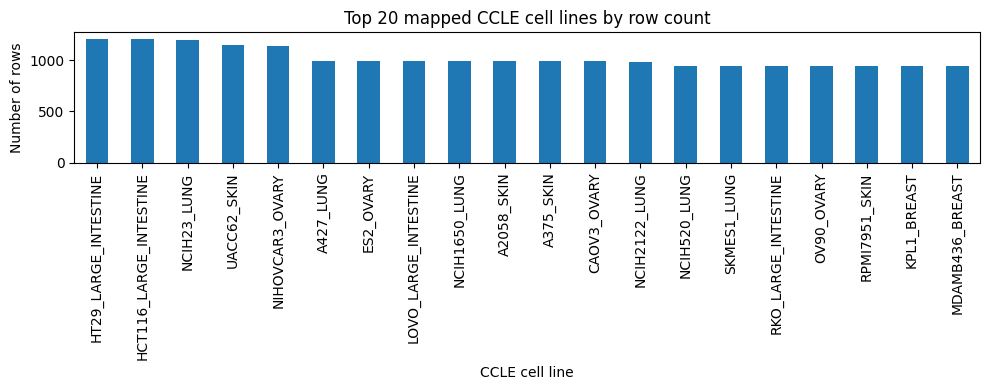

In [12]:
# 4) Quick sanity checks: sample rows & distribution by cell line
final_filtered = combined_mapped.copy()

print('Final filtered shape:', final_filtered.shape)
print('\nSample rows:')
print(final_filtered[['Drug1','Drug2','Cell line','ccle_name']].head())

print('\nTop 10 cell lines by row count:')
counts = final_filtered['ccle_name'].value_counts()
print(counts.head(10))

# Show how many unique cell lines are available after filtering
print('\nUnique mapped CCLE cell lines:', final_filtered['ccle_name'].nunique())

# Save the counts for later inspection
try:
    counts.to_csv(base / 'cell_line_counts_after_filter.csv')
    print('Wrote cell line counts to:', base / 'cell_line_counts_after_filter.csv')
except Exception as e:
    print('Could not write counts to CSV:', e)

# Quick visualization (optional)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    counts.head(20).plot(kind='bar')
    plt.title('Top 20 mapped CCLE cell lines by row count')
    plt.ylabel('Number of rows')
    plt.xlabel('CCLE cell line')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Plot skipped (matplotlib may be missing):', e)
